# Magnetometer Analysis

Analyze magnetometer readings by orientation and distance.  
Plot means with uncertainty-in-mean error bars, fit a dipole power law, and report regression statistics.

**Model:** $B(r) = B_0 + \frac{A}{(r + r_0)^3}$

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Axis label per orientation (Vertical measures x, Horizontal measures z)
AXIS_LABEL = {"Horizontal": "z", "Vertical": "x"}


In [2]:
csv_path = Path("Magnetometer_data .csv")
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

required_cols = [
    "Orientation",
    "distance from sensor (mm)",
    "magnetometer reading (z)",
    "Uncertainty in Mean",
]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

df["Orientation"] = df["Orientation"].astype(str).str.strip()
df["distance from sensor (mm)"] = pd.to_numeric(df["distance from sensor (mm)"], errors="coerce")
df["magnetometer reading (z)"] = pd.to_numeric(df["magnetometer reading (z)"], errors="coerce")
df["Uncertainty in Mean"] = pd.to_numeric(df["Uncertainty in Mean"], errors="coerce")
df = df.dropna(subset=required_cols)

agg = (
    df.groupby(["Orientation", "distance from sensor (mm)"], as_index=False)
    .agg(
        mean_reading=("magnetometer reading (z)", "mean"),
        uncertainty_mean=("Uncertainty in Mean", lambda s: (s.pow(2).sum() ** 0.5) / len(s)),
        n=("magnetometer reading (z)", "size"),
    )
    .sort_values(["Orientation", "distance from sensor (mm)"])
)
agg.head()

,Orientation,distance from sensor (mm),mean_reading,uncertainty_mean,n
0,Horizontal,15,14133.62,0.292617,1
1,Horizontal,16,11742.44,0.433458,1
2,Horizontal,17,9996.96,0.349880,1
3,Horizontal,18,8503.54,0.255886,1
4,Horizontal,19,7232.44,0.265207,1


In [3]:
summary = (
    agg.groupby("Orientation", as_index=False)
    .agg(
        n_points=("distance from sensor (mm)", "size"),
        distance_min_mm=("distance from sensor (mm)", "min"),
        distance_max_mm=("distance from sensor (mm)", "max"),
        avg_magnetometer_reading=("mean_reading", "mean"),
        avg_uncertainty_mean=("uncertainty_mean", "mean"),
    )
)
summary

,Orientation,n_points,distance_min_mm,distance_max_mm,avg_magnetometer_reading,avg_uncertainty_mean
0,Horizontal,26,15,40,3883.434615,0.240741
1,Vertical,12,24,35,1596.006250,0.343414


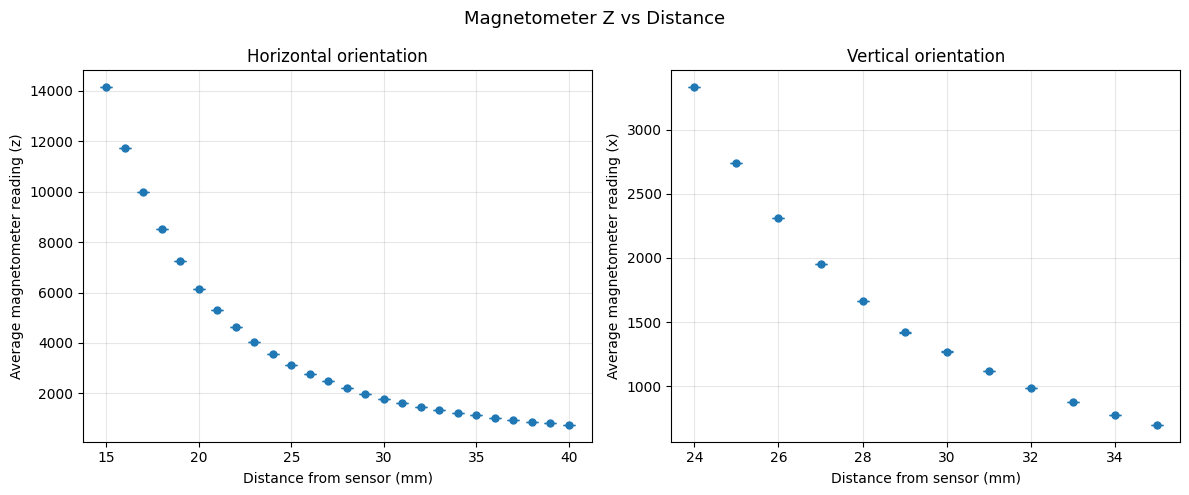

In [4]:
orientations = agg["Orientation"].unique()
fig, axes = plt.subplots(1, len(orientations), figsize=(6 * len(orientations), 5), sharey=False)
if len(orientations) == 1:
    axes = [axes]

for ax, orientation in zip(axes, orientations):
    part = agg[agg["Orientation"] == orientation].sort_values("distance from sensor (mm)")
    ax.errorbar(
        part["distance from sensor (mm)"],
        part["mean_reading"],
        yerr=part["uncertainty_mean"],
        fmt="o", capsize=4, markersize=5,
    )
    ax.set_title(f"{orientation} orientation")
    ax.set_xlabel("Distance from sensor (mm)")
    ax_label = AXIS_LABEL.get(orientation, "z")
    ax.set_ylabel(f"Average magnetometer reading ({ax_label})")
    ax.grid(alpha=0.3)

fig.suptitle("Magnetometer Z vs Distance", fontsize=13)
fig.tight_layout()
plt.show()

In [5]:
def power_law_model(r, B0, A, r0):
    return B0 + A / (r + r0) ** 3

def power_law_model_2p(r, B0, A):
    return B0 + A / r ** 3

def power_law_model_1p(r, A):
    return A / r ** 3


---
## OLS Analysis (unweighted)

Includes:
- 3-parameter model: $B(r)=B_0 + A/(r+r_0)^3$
- 2-parameter model: $B(r)=B_0 + A/r^3$
- 1-parameter model: $B(r)=A/r^3$


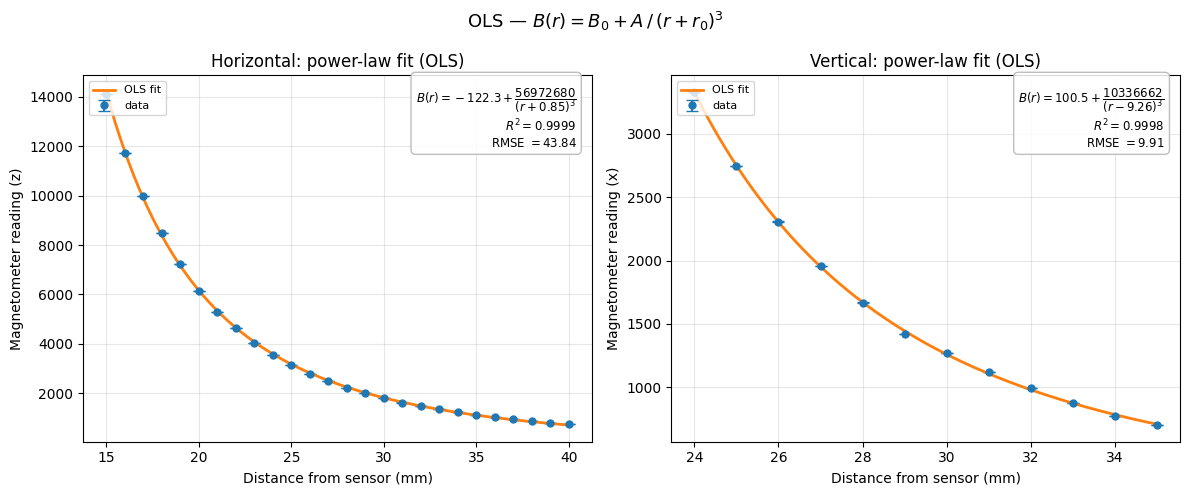

,Orientation,B0,B0_err (1σ),A,A_err (1σ),r0,r0_err (1σ),R²,RMSE,dof
0,Horizontal,-122.3180,26.6951,56972679.74,1374127.09,0.8475,0.1275,0.999851,43.8407,23
1,Vertical,100.4606,22.2462,10336661.60,598755.25,-9.2579,0.2614,0.999847,9.9097,9


In [6]:
ols_fit_params = {}  # kept for OLS linearisation cell
ols_fit_rows = []

orientations = agg["Orientation"].unique()
fig, axes = plt.subplots(1, len(orientations), figsize=(6 * len(orientations), 5), sharey=False)
if len(orientations) == 1:
    axes = [axes]

for ax, orientation in zip(axes, orientations):
    part = agg[agg["Orientation"] == orientation].sort_values("distance from sensor (mm)")
    r = part["distance from sensor (mm)"].to_numpy(dtype=float)
    B = part["mean_reading"].to_numpy(dtype=float)
    sigma = np.clip(part["uncertainty_mean"].to_numpy(dtype=float), 1e-9, None)

    B0_guess = float(np.mean(B[-3:]))
    A_guess = float((B[0] - B0_guess) * (r[0] + 1.0) ** 3)

    popt, pcov = curve_fit(
        power_law_model, r, B,
        p0=[B0_guess, A_guess, 0.0],
        maxfev=100000,
    )
    perr = np.sqrt(np.diag(pcov))
    ols_fit_params[orientation] = popt

    residuals = B - power_law_model(r, *popt)
    dof = len(r) - 3
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((B - B.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    rmse = float(np.sqrt(ss_res / len(r)))

    ols_fit_rows.append({
        "Orientation": orientation,
        "B0": round(popt[0], 4), "B0_err (1σ)": round(perr[0], 4),
        "A": round(popt[1], 2),  "A_err (1σ)": round(perr[1], 2),
        "r0": round(popt[2], 4), "r0_err (1σ)": round(perr[2], 4),
        "R²": round(r2, 6), "RMSE": round(rmse, 4), "dof": dof,
    })

    ax.errorbar(r, B, yerr=sigma, fmt="o", capsize=4, markersize=5, label="data")
    r_fit = np.linspace(r.min(), r.max(), 300)
    ax.plot(r_fit, power_law_model(r_fit, *popt), "-", linewidth=2, label="OLS fit")

    sign_r0 = "+" if popt[2] >= 0 else "-"
    eq_str = (
        f"$B(r) = {popt[0]:.1f} + \\dfrac{{{popt[1]:.0f}}}{{(r {sign_r0} {abs(popt[2]):.2f})^3}}$\n"
        f"$R^2 = {r2:.4f}$\n"
        f"RMSE $= {rmse:.2f}$"
    )
    ax.text(
        0.97, 0.97, eq_str,
        transform=ax.transAxes,
        fontsize=8.5, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )
    ax.set_title(f"{orientation}: power-law fit (OLS)")
    ax.set_xlabel("Distance from sensor (mm)")
    ax_label = AXIS_LABEL.get(orientation, "z")
    ax.set_ylabel(f"Magnetometer reading ({ax_label})")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

fig.suptitle(r"OLS — $B(r) = B_0 + A\,/\,(r+r_0)^3$", fontsize=13)
fig.tight_layout()
plt.show()

pd.DataFrame(ols_fit_rows)


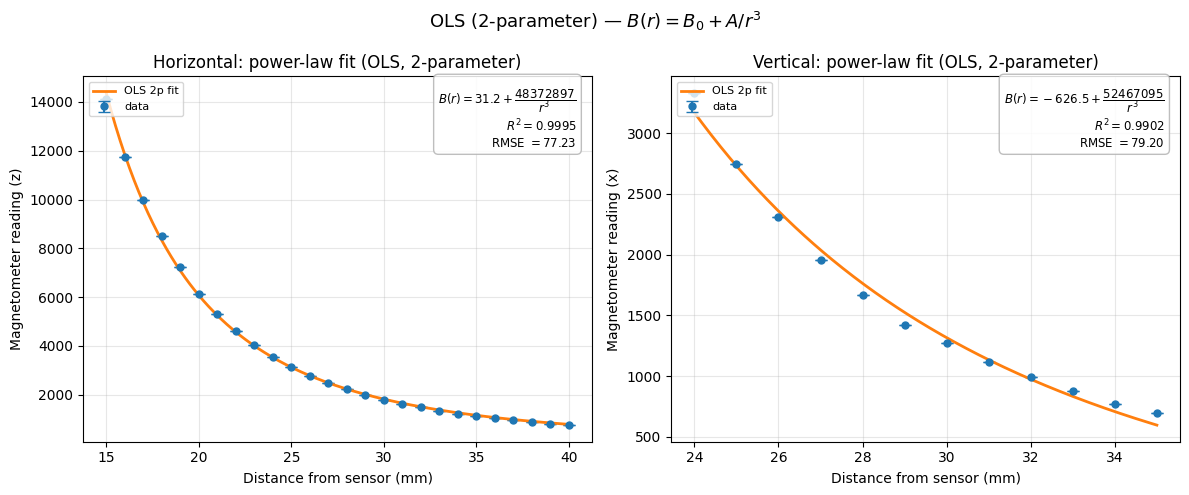

,Orientation,B0,B0_err (1σ),A,A_err (1σ),R²,RMSE,dof
0,Horizontal,31.2474,23.1102,48372897.00,212211.13,0.999538,77.2252,24
1,Vertical,-626.4545,74.2140,52467095.16,1649237.82,0.990216,79.1994,10


In [7]:
ols2_fit_params = {}
ols2_fit_rows = []

orientations = agg["Orientation"].unique()
fig, axes = plt.subplots(1, len(orientations), figsize=(6 * len(orientations), 5), sharey=False)
if len(orientations) == 1:
    axes = [axes]

for ax, orientation in zip(axes, orientations):
    part = agg[agg["Orientation"] == orientation].sort_values("distance from sensor (mm)")
    r = part["distance from sensor (mm)"].to_numpy(dtype=float)
    B = part["mean_reading"].to_numpy(dtype=float)
    sigma = np.clip(part["uncertainty_mean"].to_numpy(dtype=float), 1e-9, None)

    B0_guess = float(np.mean(B[-3:]))
    A_guess = float((B[0] - B0_guess) * (r[0] ** 3))

    popt, pcov = curve_fit(
        power_law_model_2p, r, B,
        p0=[B0_guess, A_guess],
        maxfev=100000,
    )
    perr = np.sqrt(np.diag(pcov))
    ols2_fit_params[orientation] = popt

    residuals = B - power_law_model_2p(r, *popt)
    dof = len(r) - 2
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((B - B.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    rmse = float(np.sqrt(ss_res / len(r)))

    ols2_fit_rows.append({
        "Orientation": orientation,
        "B0": round(popt[0], 4), "B0_err (1σ)": round(perr[0], 4),
        "A": round(popt[1], 2),  "A_err (1σ)": round(perr[1], 2),
        "R²": round(r2, 6), "RMSE": round(rmse, 4), "dof": dof,
    })

    ax.errorbar(r, B, yerr=sigma, fmt="o", capsize=4, markersize=5, label="data")
    r_fit = np.linspace(r.min(), r.max(), 300)
    ax.plot(r_fit, power_law_model_2p(r_fit, *popt), "-", linewidth=2, label="OLS 2p fit")

    eq_str = (
        f"$B(r) = {popt[0]:.1f} + \dfrac{{{popt[1]:.0f}}}{{r^3}}$\n"
        f"$R^2 = {r2:.4f}$\n"
        f"RMSE $= {rmse:.2f}$"
    )
    ax.text(
        0.97, 0.97, eq_str,
        transform=ax.transAxes,
        fontsize=8.5, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )
    ax.set_title(f"{orientation}: power-law fit (OLS, 2-parameter)")
    ax.set_xlabel("Distance from sensor (mm)")
    ax_label = AXIS_LABEL.get(orientation, "z")
    ax.set_ylabel(f"Magnetometer reading ({ax_label})")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

fig.suptitle(r"OLS (2-parameter) — $B(r) = B_0 + A/r^3$", fontsize=13)
fig.tight_layout()
plt.show()

pd.DataFrame(ols2_fit_rows)


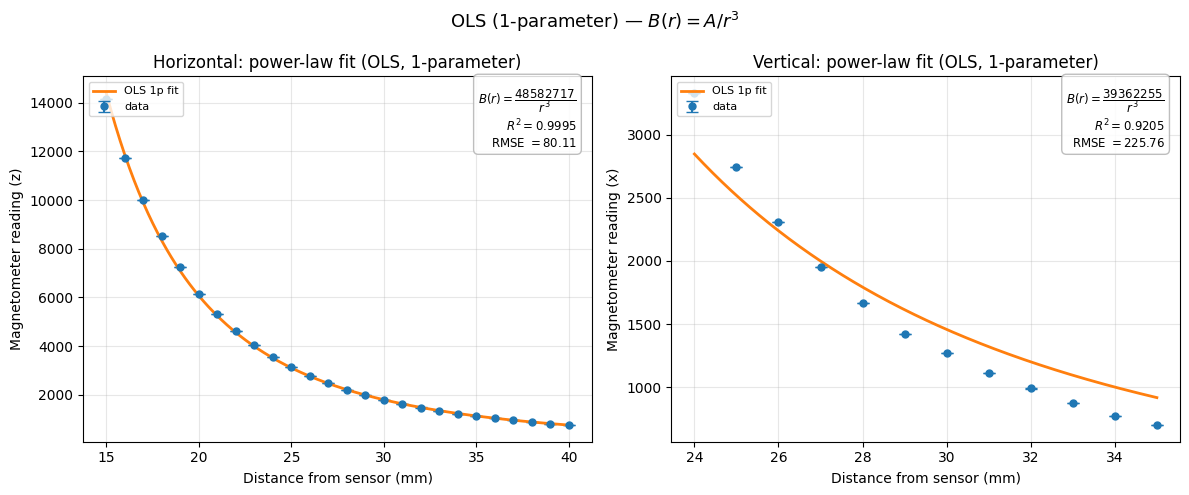

,Orientation,A,A_err (1σ),R²,RMSE,dof
0,Horizontal,48582717.33,147127.79,0.999503,80.1125,25
1,Vertical,39362254.84,1512672.72,0.920500,225.7583,11


In [8]:
ols1_fit_params = {}
ols1_fit_rows = []

orientations = agg["Orientation"].unique()
fig, axes = plt.subplots(1, len(orientations), figsize=(6 * len(orientations), 5), sharey=False)
if len(orientations) == 1:
    axes = [axes]

for ax, orientation in zip(axes, orientations):
    part = agg[agg["Orientation"] == orientation].sort_values("distance from sensor (mm)")
    r = part["distance from sensor (mm)"].to_numpy(dtype=float)
    B = part["mean_reading"].to_numpy(dtype=float)
    sigma = np.clip(part["uncertainty_mean"].to_numpy(dtype=float), 1e-9, None)

    A_guess = float(B[0] * (r[0] ** 3))

    popt, pcov = curve_fit(
        power_law_model_1p, r, B,
        p0=[A_guess],
        maxfev=100000,
    )
    perr = np.sqrt(np.diag(pcov))
    ols1_fit_params[orientation] = popt[0]

    residuals = B - power_law_model_1p(r, *popt)
    dof = len(r) - 1
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((B - B.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    rmse = float(np.sqrt(ss_res / len(r)))

    ols1_fit_rows.append({
        "Orientation": orientation,
        "A": round(popt[0], 2), "A_err (1σ)": round(perr[0], 2),
        "R²": round(r2, 6), "RMSE": round(rmse, 4), "dof": dof,
    })

    ax.errorbar(r, B, yerr=sigma, fmt="o", capsize=4, markersize=5, label="data")
    r_fit = np.linspace(r.min(), r.max(), 300)
    ax.plot(r_fit, power_law_model_1p(r_fit, *popt), "-", linewidth=2, label="OLS 1p fit")

    eq_str = (
        f"$B(r) = \\dfrac{{{popt[0]:.0f}}}{{r^3}}$\n"
        f"$R^2 = {r2:.4f}$\n"
        f"RMSE $= {rmse:.2f}$"
    )
    ax.text(
        0.97, 0.97, eq_str,
        transform=ax.transAxes,
        fontsize=8.5, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )
    ax.set_title(f"{orientation}: power-law fit (OLS, 1-parameter)")
    ax.set_xlabel("Distance from sensor (mm)")
    ax_label = AXIS_LABEL.get(orientation, "z")
    ax.set_ylabel(f"Magnetometer reading ({ax_label})")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

fig.suptitle(r"OLS (1-parameter) — $B(r) = A/r^3$", fontsize=13)
fig.tight_layout()
plt.show()

pd.DataFrame(ols1_fit_rows)


In [13]:
"""
Model comparison: AIC, BIC, adjusted R² across all three OLS fits.

AIC = n·ln(RSS/n) + 2k
BIC = n·ln(RSS/n) + k·ln(n)

Lower AIC/BIC = better model (penalises extra parameters).
"""

required = {
    "3-parameter (B0+A/(r+r0)^3)": ("ols_fit_rows",  3),
    "2-parameter (B0+A/r^3)":       ("ols2_fit_rows", 2),
    "1-parameter (A/r^3)":          ("ols1_fit_rows", 1),
}
for label, (var, _) in required.items():
    if var not in globals():
        raise RuntimeError(f"Run the {label} fit cell first (missing `{var}`).")

def compute_aic_bic(ss_res, n, k):
    log_term = np.log(ss_res / n) if ss_res > 0 else float("nan")
    aic = n * log_term + 2 * k
    bic = n * log_term + k * np.log(n)
    return aic, bic

comparison_rows = []
for orientation in agg["Orientation"].unique():
    part = agg[agg["Orientation"] == orientation].sort_values("distance from sensor (mm)")
    r = part["distance from sensor (mm)"].to_numpy(dtype=float)
    B = part["mean_reading"].to_numpy(dtype=float)
    n = len(r)

    for label, (var_name, k) in required.items():
        rows_list = globals()[var_name]
        row = next(d for d in rows_list if d["Orientation"] == orientation)

        rmse = row["RMSE"]
        ss_res = (rmse ** 2) * n
        ss_tot = float(np.sum((B - B.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot
        adj_r2 = 1.0 - (1 - r2) * (n - 1) / (n - k - 1)
        aic, bic = compute_aic_bic(ss_res, n, k)

        comparison_rows.append({
            "Orientation": orientation,
            "Model": label,
            "k (params)": k,
            "n (points)": n,
            "R²": round(r2, 6),
            "Adj. R²": round(adj_r2, 6),
            "AIC": round(aic, 3),
            "BIC": round(bic, 3),
            "RMSE": round(rmse, 4),
        })

comp_df = pd.DataFrame(comparison_rows)

# Highlight best (lowest AIC/BIC) per orientation
for orient in comp_df["Orientation"].unique():
    mask = comp_df["Orientation"] == orient
    best_aic = comp_df.loc[mask, "AIC"].idxmin()
    best_bic = comp_df.loc[mask, "BIC"].idxmin()
    print(f"=== {orient} ===")
    print(f"  Best AIC → {comp_df.loc[best_aic, 'Model']}")
    print(f"  Best BIC → {comp_df.loc[best_bic, 'Model']}")
    print()

comp_df

=== Horizontal ===
  Best AIC → 3-parameter (B0+A/(r+r0)^3)
  Best BIC → 3-parameter (B0+A/(r+r0)^3)

=== Vertical ===
  Best AIC → 3-parameter (B0+A/(r+r0)^3)
  Best BIC → 3-parameter (B0+A/(r+r0)^3)



,Orientation,Model,k (params),n (points),R²,Adj. R²,AIC,BIC,RMSE
0,Horizontal,3-parameter (B0+A/(r+r0)^3),3,26,0.999851,0.999831,202.589,206.364,43.8407
1,Horizontal,2-parameter (B0+A/r^3),2,26,0.999538,0.999498,230.030,232.546,77.2252
2,Horizontal,1-parameter (A/r^3),1,26,0.999503,0.999482,229.938,231.197,80.1125
3,Vertical,3-parameter (B0+A/(r+r0)^3),3,12,0.999847,0.999789,61.044,62.499,9.9097
4,Vertical,2-parameter (B0+A/r^3),2,12,0.990216,0.988042,108.927,109.897,79.1994
5,Vertical,1-parameter (A/r^3),1,12,0.920500,0.912550,132.067,132.552,225.7583


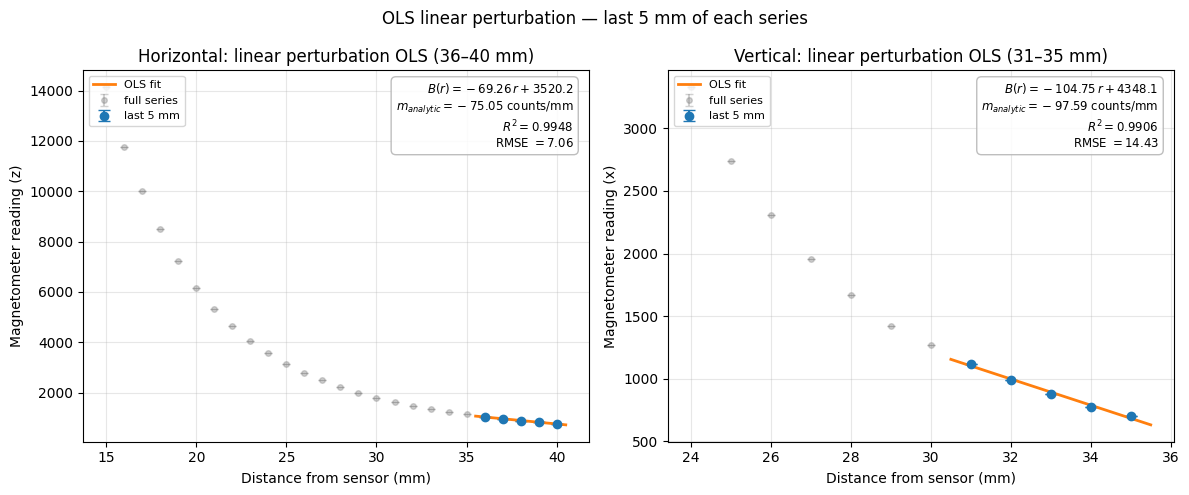

,Orientation,window (mm),n_points,slope m (counts/mm),m_err (1σ),intercept c,c_err (1σ),analytic dB/dr,R²,RMSE
0,Horizontal,36–40,5,-69.26,2.8832,3520.22,109.64,-75.0474,0.994828,7.0624
1,Vertical,31–35,5,-104.75,5.8916,4348.11,194.60,-97.5945,0.990599,14.4315


In [9]:
WINDOW_MM = 5

ols_lin_rows = []

orientations = agg["Orientation"].unique()
fig, axes = plt.subplots(1, len(orientations), figsize=(6 * len(orientations), 5), sharey=False)
if len(orientations) == 1:
    axes = [axes]

for ax, orientation in zip(axes, orientations):
    part = agg[agg["Orientation"] == orientation].sort_values("distance from sensor (mm)")
    r_all = part["distance from sensor (mm)"].to_numpy(dtype=float)
    B_all = part["mean_reading"].to_numpy(dtype=float)
    s_all = np.clip(part["uncertainty_mean"].to_numpy(dtype=float), 1e-9, None)

    mask = r_all >= (r_all.max() - WINDOW_MM + 1)
    r_win = r_all[mask]
    B_win = B_all[mask]
    s_win = s_all[mask]

    m_fit, c_fit = np.polyfit(r_win, B_win, 1)
    B_lin_pred = m_fit * r_win + c_fit
    residuals = B_win - B_lin_pred
    n_w = len(r_win)
    dof = max(n_w - 2, 1)
    s2 = float(np.sum(residuals ** 2)) / dof
    Sxx = float(np.sum((r_win - r_win.mean()) ** 2))
    m_err = float(np.sqrt(s2 / Sxx)) if Sxx > 0 else float("nan")
    c_err = float(np.sqrt(s2 * float(np.sum(r_win ** 2)) / (n_w * Sxx))) if Sxx > 0 else float("nan")
    ss_res = float(np.sum(residuals ** 2))
    rmse = float(np.sqrt(ss_res / n_w))
    ss_tot = float(np.sum((B_win - B_win.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    r_mid = float(np.mean(r_win))
    B0_pl, A_pl, r0_pl = ols_fit_params[orientation]
    m_analytic = -3.0 * A_pl / (r_mid + r0_pl) ** 4

    ols_lin_rows.append({
        "Orientation": orientation,
        "window (mm)": f"{int(r_win.min())}–{int(r_win.max())}",
        "n_points": int(mask.sum()),
        "slope m (counts/mm)": round(m_fit, 4),
        "m_err (1σ)": round(m_err, 4),
        "intercept c": round(c_fit, 2),
        "c_err (1σ)": round(c_err, 2),
        "analytic dB/dr": round(m_analytic, 4),
        "R²": round(r2, 6),
        "RMSE": round(rmse, 4),
    })

    ax.errorbar(r_all, B_all, yerr=s_all, fmt="o", capsize=3, markersize=4,
                color="tab:grey", alpha=0.35, label="full series")
    ax.errorbar(r_win, B_win, yerr=s_win, fmt="o", capsize=4, markersize=6,
                label=f"last {WINDOW_MM} mm")
    r_line = np.linspace(r_win.min() - 0.5, r_win.max() + 0.5, 100)
    ax.plot(r_line, m_fit * r_line + c_fit, "-", linewidth=2, label="OLS fit")

    sign_c = "+" if c_fit >= 0 else "-"
    eq_str = (
        f"$B(r) = {m_fit:.2f}\\,r {sign_c} {abs(c_fit):.1f}$\n"
        f"$m_{{analytic}} = {m_analytic:.2f}$ counts/mm\n"
        f"$R^2 = {r2:.4f}$\n"
        f"RMSE $= {rmse:.2f}$"
    )
    ax.text(
        0.97, 0.97, eq_str,
        transform=ax.transAxes,
        fontsize=8.5, verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )
    ax.set_title(f"{orientation}: linear perturbation OLS ({r_win.min():.0f}–{r_win.max():.0f} mm)")
    ax.set_xlabel("Distance from sensor (mm)")
    ax_label = AXIS_LABEL.get(orientation, "z")
    ax.set_ylabel(f"Magnetometer reading ({ax_label})")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

fig.suptitle(f"OLS linear perturbation — last {WINDOW_MM} mm of each series", fontsize=12)
fig.tight_layout()
plt.show()

pd.DataFrame(ols_lin_rows)


In [12]:
# --- Load-to-field resolution using OLS 2-parameter power-law fit ---
# Choose setup parameters
start_distance_mm = 7
end_distance_mm = 7.5
max_load_kg = 70
interval_kg = 10

# Set to a specific orientation (e.g. "Horizontal") or None for all.
selected_orientation = 'Horizontal'


def load_to_distance(load_kg, start_mm, end_mm, max_kg):
    """Linear load->distance mapping across the chosen mechanical travel."""
    return start_mm + (end_mm - start_mm) * (load_kg / max_kg)


if "ols2_fit_params" not in globals():
    raise RuntimeError("Run the OLS 2-parameter fit cell first so `ols2_fit_params` is available.")

if max_load_kg <= 0:
    raise ValueError("max_load_kg must be > 0")
if interval_kg <= 0:
    raise ValueError("interval_kg must be > 0")
if interval_kg > max_load_kg:
    raise ValueError("interval_kg cannot be greater than max_load_kg")

loads = np.arange(0, max_load_kg + interval_kg, interval_kg, dtype=float)
if loads[-1] > max_load_kg:
    loads[-1] = float(max_load_kg)
elif loads[-1] < max_load_kg:
    loads = np.append(loads, float(max_load_kg))

orientations = [selected_orientation] if selected_orientation else list(ols2_fit_params.keys())
rows = []

for orientation in orientations:
    if orientation not in ols2_fit_params:
        raise ValueError(f"Orientation '{orientation}' not found in ols2_fit_params")

    B0, A = ols2_fit_params[orientation]
    distances = load_to_distance(loads, start_distance_mm, end_distance_mm, max_load_kg)
    fields = power_law_model_2p(distances, B0, A)

    for i, load in enumerate(loads):
        step_start = max(0.0, load - interval_kg)
        dB_step = np.nan if i == 0 else fields[i] - fields[i - 1]
        resolution_per_kg = np.nan if i == 0 else dB_step / (load - loads[i - 1])

        rows.append(
            {
                "Orientation": orientation,
                "Load start (kg)": round(step_start, 3),
                "Load end (kg)": round(load, 3),
                "Distance at load end (mm)": round(float(distances[i]), 4),
                "Predicted field at load end": round(float(fields[i]), 6),
                f"ΔB over last {interval_kg} kg": np.nan if i == 0 else round(float(dB_step), 6),
                "Resolution (field units / kg)": np.nan if i == 0 else round(float(resolution_per_kg), 6),
            }
        )

resolution_df = pd.DataFrame(rows)

print(f"Model: B(r) = B0 + A/r³  [2-parameter]")
print(f"Distance range: {start_distance_mm} mm -> {end_distance_mm} mm")
print(f"Load range: 0 kg -> {max_load_kg} kg in {interval_kg} kg steps")
resolution_df

Model: B(r) = B0 + A/r³  [2-parameter]
Distance range: 15.0 mm -> 15.5 mm
Load range: 0 kg -> 70 kg in 10 kg steps


,Orientation,Load start (kg),Load end (kg),Distance at load end (mm),Predicted field at load end,ΔB over last 10 kg,Resolution (field units / kg)
0,Horizontal,0.0,0.0,15.0000,14363.957600,NaN,NaN
1,Horizontal,0.0,10.0,15.0714,14161.139259,-202.818341,-20.281834
2,Horizontal,10.0,20.0,15.1429,13962.129642,-199.009617,-19.900962
3,Horizontal,20.0,30.0,15.2143,13766.839763,-195.289879,-19.528988
4,Horizontal,30.0,40.0,15.2857,13575.183118,-191.656645,-19.165665
5,Horizontal,40.0,50.0,15.3571,13387.075606,-188.107512,-18.810751
6,Horizontal,50.0,60.0,15.4286,13202.435452,-184.640154,-18.464015
7,Horizontal,60.0,70.0,15.5000,13021.183130,-181.252322,-18.125232
